# 4. Channel decomposition benchmark notebook

这个 notebook 检查 `channels.py`。

目标：

- `pp / ph_direct / ph_crossed` 的 kernel 定义是否和 `interaction.patch_vertex` 一致
- shifted patch mapping 的 residual 是否太大
- 在最简单的 SU(2)-symmetric 情况下，不同 spin block 是否一致
- kernel 是否有合理的 Hermitian / symmetry 表现

这一步不等于 full FRG flow；它只是验证你现在的 channel bookkeeping 是否有明显的物理逻辑错误。


In [1]:
import os, sys, math, cmath
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '/mnt/data')

from noninteracting import KagomeNagaosa, KagomeStaggerFlux, KagomeKaneMeleSOC
from patching import FSPatcher
from interaction import BareExtendedHubbard
from channels import ChannelDecomposer

RESULTS = []

def record(name, passed, detail='', value=None):
    RESULTS.append({
        'test': name,
        'passed': bool(passed),
        'detail': str(detail),
        'value': value,
    })

def check(name, cond, detail_ok='', detail_fail='', value=None):
    if cond:
        record(name, True, detail_ok, value)
    else:
        record(name, False, detail_fail, value)


def summarize_results():
    n_pass = sum(r['passed'] for r in RESULTS)
    n_fail = len(RESULTS) - n_pass
    print('='*90)
    print(f'Total tests: {len(RESULTS)} | PASS: {n_pass} | FAIL: {n_fail}')
    print('='*90)
    for i, r in enumerate(RESULTS, 1):
        flag = 'PASS' if r['passed'] else 'FAIL'
        print(f"[{i:02d}] {flag:4s} | {r['test']}")
        if r['detail']:
            print('     ', r['detail'])
        if r['value'] is not None:
            print('     value =', r['value'])
    print('='*90)
    return n_fail


In [2]:
# 你可以改这里
model = KagomeKaneMeleSOC(parameters={'t': 1.0, 'l1': 0.0, 'l2': 0.0}, spin=True, B=0.0)
mu = model.EF_from_filling(5/12, N=100, tol=1e-4)
print('mu =', mu)

patcher_up = FSPatcher(model=model, band_index=1, mu=mu, Npatch=12, grid_size=220, orbital_slice=slice(0,3), verbose=False)
patcher_dn = FSPatcher(model=model, band_index=1, mu=mu, Npatch=12, grid_size=220, orbital_slice=slice(3,6), verbose=False)
ps_up = patcher_up.build()
ps_dn = patcher_dn.build()
patchsets = {'up': ps_up, 'dn': ps_dn}

interaction = BareExtendedHubbard.from_kagome_model(model, U=2.0, V=1.0)
decomp = ChannelDecomposer(interaction, patchsets)


mu = -3.0083462602747215e-17


In [3]:
# 1) manual reconstruction of pp kernel
Q = np.zeros(2)
Kpp = decomp.pp_kernel(Q, incoming_spins=('up','dn'), outgoing_spins=('up','dn'))
N = Kpp.matrix.shape[0]
M_manual = np.zeros_like(Kpp.matrix)
for pout in range(N):
    p4 = int(Kpp.row_partner_patches[pout])
    for pin in range(N):
        p2 = int(Kpp.col_partner_patches[pin])
        M_manual[pout, pin] = interaction.patch_vertex(
            patchsets,
            pin, 'up',
            p2,  'dn',
            pout,'up',
            p4,  'dn',
            antisym=True,
            check_momentum=False,
        )
err = np.max(np.abs(Kpp.matrix - M_manual))
check(
    'pp kernel matches manual reconstruction',
    err < 1e-12,
    detail_ok=f'max entrywise diff = {err:.3e}',
    detail_fail=f'pp kernel definition mismatch: max diff = {err:.3e}',
    value=float(err),
)


In [4]:
# 2) manual reconstruction of ph-direct kernel
Q = np.zeros(2)
Kphd = decomp.ph_direct_kernel(Q, incoming_spins=('up','up'), outgoing_spins=('up','up'))
N = Kphd.matrix.shape[0]
M_manual = np.zeros_like(Kphd.matrix)
for pout in range(N):
    p2 = int(Kphd.row_partner_patches[pout])
    for pin in range(N):
        p3 = int(Kphd.col_partner_patches[pin])
        M_manual[pout, pin] = interaction.patch_vertex(
            patchsets,
            pin, 'up',
            p2,  'up',
            p3,  'up',
            pout,'up',
            antisym=True,
            check_momentum=False,
        )
err = np.max(np.abs(Kphd.matrix - M_manual))
check(
    'ph-direct kernel matches manual reconstruction',
    err < 1e-12,
    detail_ok=f'max entrywise diff = {err:.3e}',
    detail_fail=f'ph-direct kernel definition mismatch: max diff = {err:.3e}',
    value=float(err),
)


In [5]:
# 3) manual reconstruction of ph-crossed kernel
Q = np.zeros(2)
Kphc = decomp.ph_crossed_kernel(Q, incoming_spins=('up','up'), outgoing_spins=('up','up'))
N = Kphc.matrix.shape[0]
M_manual = np.zeros_like(Kphc.matrix)
for pout in range(N):
    p3 = int(Kphc.row_partner_patches[pout])
    for pin in range(N):
        p4 = int(Kphc.col_partner_patches[pin])
        M_manual[pout, pin] = interaction.patch_vertex(
            patchsets,
            pin, 'up',
            pout,'up',
            p3,  'up',
            p4,  'up',
            antisym=True,
            check_momentum=False,
        )
err = np.max(np.abs(Kphc.matrix - M_manual))
check(
    'ph-crossed kernel matches manual reconstruction',
    err < 1e-12,
    detail_ok=f'max entrywise diff = {err:.3e}',
    detail_fail=f'ph-crossed kernel definition mismatch: max diff = {err:.3e}',
    value=float(err),
)


In [6]:
# 4) residual benchmark
for name, K in [('pp', Kpp), ('ph_direct', Kphd), ('ph_crossed', Kphc)]:
    rmax = float(np.max(K.residuals))
    rmean = float(np.mean(K.residuals))
    check(
        f'{name} shifted-patch residual not too large',
        rmean < 3e-1,
        detail_ok=f'mean residual={rmean:.3e}, max residual={rmax:.3e}',
        detail_fail=f'residual maybe too large: mean={rmean:.3e}, max={rmax:.3e}',
        value={'mean': rmean, 'max': rmax},
    )


In [7]:
# 5) SU(2)-symmetric trivial model: uu_to_uu and dd_to_dd pp blocks should match
blocks = decomp.pp_spin_blocks(np.zeros(2))
if 'uu_to_uu' in blocks and 'dd_to_dd' in blocks:
    err = np.max(np.abs(blocks['uu_to_uu'].matrix - blocks['dd_to_dd'].matrix))
    check(
        'pp same-spin uu and dd blocks coincide in trivial SU(2) model',
        err < 1e-10,
        detail_ok=f'max diff = {err:.3e}',
        detail_fail=f'uu and dd pp blocks differ: max diff = {err:.3e}',
        value=float(err),
    )
else:
    check('pp same-spin uu/dd blocks exist', False, detail_fail='uu_to_uu or dd_to_dd block missing unexpectedly')


In [8]:
# 6) mixed-spin ud_to_ud and du_to_du should also match in this trivial model
if ('ud_to_ud' in blocks) and ('du_to_du' in blocks):
    err = np.max(np.abs(blocks['ud_to_ud'].matrix - blocks['du_to_du'].matrix))
    check(
        'pp mixed-spin ud_to_ud and du_to_du coincide',
        err < 1e-10,
        detail_ok=f'max diff = {err:.3e}',
        detail_fail=f'ud_to_ud and du_to_du differ: max diff = {err:.3e}',
        value=float(err),
    )
else:
    check('pp mixed-spin blocks exist', False, detail_fail='ud_to_ud or du_to_du block missing unexpectedly')


In [9]:
# 7) Hermitian residuals: 这里不强行要求所有 kernel 都严格 Hermitian，
# 但至少把数值打印出来，帮助定位严重异常
for name, K in [('pp', Kpp), ('ph_direct', Kphd), ('ph_crossed', Kphc)]:
    hr = K.hermitian_residual()
    print(f'{name}: hermitian residual = {hr:.6e}')


pp: hermitian residual = 2.220446e-16
ph_direct: hermitian residual = 2.220446e-16
ph_crossed: hermitian residual = 2.220446e-16


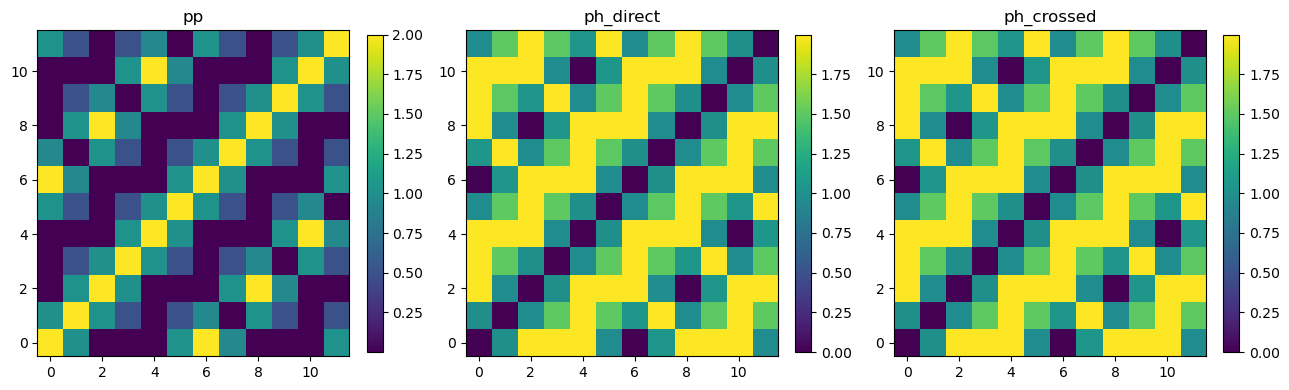

In [10]:
# 8) optional quick visualization of absolute values
fig, axes = plt.subplots(1,3, figsize=(13,4))
for ax, K, title in zip(axes, [Kpp, Kphd, Kphc], ['pp', 'ph_direct', 'ph_crossed']):
    im = ax.imshow(np.abs(K.matrix), origin='lower', aspect='auto')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


In [11]:
summarize_results()


Total tests: 8 | PASS: 8 | FAIL: 0
[01] PASS | pp kernel matches manual reconstruction
      max entrywise diff = 0.000e+00
     value = 0.0
[02] PASS | ph-direct kernel matches manual reconstruction
      max entrywise diff = 0.000e+00
     value = 0.0
[03] PASS | ph-crossed kernel matches manual reconstruction
      max entrywise diff = 0.000e+00
     value = 0.0
[04] PASS | pp shifted-patch residual not too large
      mean residual=1.640e-03, max residual=1.723e-03
     value = {'mean': 0.0016396192870311893, 'max': 0.0017226637881072096}
[05] PASS | ph_direct shifted-patch residual not too large
      mean residual=0.000e+00, max residual=0.000e+00
     value = {'mean': 0.0, 'max': 0.0}
[06] PASS | ph_crossed shifted-patch residual not too large
      mean residual=0.000e+00, max residual=0.000e+00
     value = {'mean': 0.0, 'max': 0.0}
[07] PASS | pp same-spin uu and dd blocks coincide in trivial SU(2) model
      max diff = 0.000e+00
     value = 0.0
[08] PASS | pp mixed-spin ud

0